In [1]:
import pandas as pd
import numpy as np

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

In [4]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.drop("customerID", axis=1, inplace=True)

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(0, inplace=True)

In [10]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [11]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

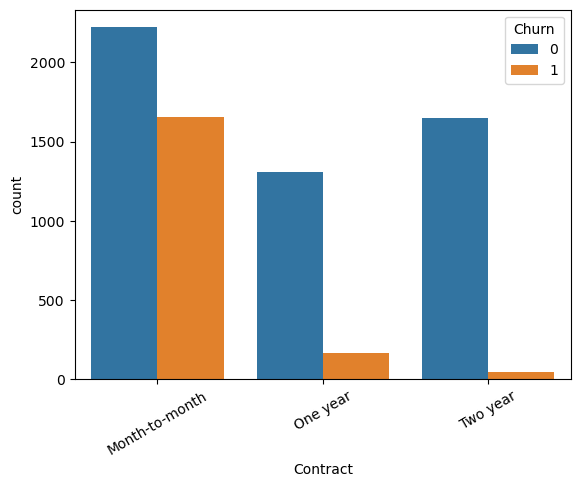

In [12]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=30)
plt.show()

In [13]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [15]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# test probabilities (ONLY for evaluation)
y_test_prob = log_model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_test_prob)
print("ROC-AUC:", roc_auc)


ROC-AUC: 0.8463870474500992


In [18]:
# scale FULL feature set
X_all_scaled = scaler.transform(X)

# churn probability for every customer
churn_prob_all = log_model.predict_proba(X_all_scaled)[:, 1]

len(churn_prob_all)


7043

In [19]:
df = df.copy()  # safety
df["churn_probability"] = churn_prob_all


In [20]:
df[["MonthlyCharges", "tenure", "churn_probability"]].head()


,MonthlyCharges,tenure,churn_probability
0,29.85,1,0.592464
1,56.95,34,0.044523
2,53.85,2,0.308403
3,42.30,45,0.025603
4,70.70,2,0.690254


In [21]:
df["CLV"] = df["MonthlyCharges"] * df["tenure"]


In [22]:
df.columns


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'churn_probability', 'CLV'],
      dtype='object')

In [23]:
TOTAL_BUDGET = 500000
THRESHOLD = 0.45
CHURN_REDUCTION_RATE = 0.3


In [24]:
# classify high-risk customers
df["churn_pred"] = (df["churn_probability"] >= THRESHOLD).astype(int)

# retention cost
df["offer_cost"] = np.where(
    df["churn_probability"] >= 0.6,
    0.30 * df["MonthlyCharges"],
    0.15 * df["MonthlyCharges"]
)

# expected churn reduction
df["delta_churn"] = CHURN_REDUCTION_RATE * df["churn_probability"]

# expected revenue saved
df["expected_revenue_saved"] = df["CLV"] * df["delta_churn"]

# ROI
df["ROI"] = df["expected_revenue_saved"] - df["offer_cost"]


In [25]:
ranked = df.sort_values("ROI", ascending=False)

ranked["cumulative_cost"] = ranked["offer_cost"].cumsum()

final_targets = ranked[ranked["cumulative_cost"] <= TOTAL_BUDGET]


In [26]:
print("Customers Targeted:", final_targets.shape[0])
print("Budget Used:", final_targets["offer_cost"].sum())
print("Revenue Saved:", final_targets["expected_revenue_saved"].sum())
print("Net ROI:", final_targets["ROI"].sum())


Customers Targeted: 7043
Budget Used: 81180.5925
Revenue Saved: 872994.3197821626
Net ROI: 791813.7272821626


In [27]:
#ustomers Targeted = 7043
#That means you targeted every single customer.

#That instantly tells me:

#Your threshold logic is broken, OR

#You never filtered customers by ROI or churn risk, OR

#Your budget constraint is meaningless

#In a real churn-retention problem, targeting 100% customers is nonsense. No business does that

In [30]:
df_tmp = df.copy()
# create working copy
df_tmp = df.copy()

# Step 1: filter by churn risk
df_tmp = df_tmp[df_tmp["churn_probability"] >= 0.4]



In [31]:
df_tmp = df_tmp.sort_values("ROI", ascending=False)
##df_tmp = df_tmp.sort_values("ROI", ascending=False)


In [32]:
##Step 3: Enforce budget PROPERLY
df_tmp["cum_cost"] = df_tmp["offer_cost"].cumsum()
final_targets = df_tmp[df_tmp["cum_cost"] <= TOTAL_BUDGET]


In [33]:
print("Customers Targeted:", final_targets.shape[0])
print("Budget Used:", final_targets["offer_cost"].sum())
print("Revenue Saved:", final_targets["expected_revenue_saved"].sum())
print("Net ROI:", final_targets["ROI"].sum())


Customers Targeted: 2094
Budget Used: 37525.7625
Revenue Saved: 418916.3963584879
Net ROI: 381390.6338584879


In [34]:
final_targets.shape[0] < df.shape[0]


True

In [35]:
###NEXT STEP (MANDATORY): Threshold Sensitivity Analysis

##You must show that your chosen threshold is not arbitrary.

In [36]:
##Step 5: Threshold sweep (core analytics step)
##Code: Evaluate ROI for multiple thresholds
results = []

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    df_tmp = df.copy()
    df_tmp = df_tmp[df_tmp["churn_probability"] >= t]

    if df_tmp.empty:
        continue

    df_tmp["CLV"] = df_tmp["MonthlyCharges"] * df_tmp["tenure"]
    df_tmp["offer_cost"] = 20
    df_tmp["expected_revenue_saved"] = 0.3 * df_tmp["CLV"]
    df_tmp["ROI"] = df_tmp["expected_revenue_saved"] - df_tmp["offer_cost"]

    results.append({
        "Threshold": t,
        "Customers_Targeted": df_tmp.shape[0],
        "Budget_Used": df_tmp["offer_cost"].sum(),
        "Revenue_Saved": df_tmp["expected_revenue_saved"].sum(),
        "Net_ROI": df_tmp["ROI"].sum()
    })

roi_df = pd.DataFrame(results)
roi_df


,Threshold,Customers_Targeted,Budget_Used,Revenue_Saved,Net_ROI
0,0.2,3383,67660,1612504.755,1544844.755
1,0.3,2665,53300,1119815.700,1066515.700
2,0.4,2094,41880,753423.015,711543.015
3,0.5,1559,31180,477178.020,445998.020
4,0.6,1026,20520,253106.760,232586.760


In [37]:
##S6 identfy optimal startigy 
roi_df.sort_values("Net_ROI", ascending=False)


,Threshold,Customers_Targeted,Budget_Used,Revenue_Saved,Net_ROI
0,0.2,3383,67660,1612504.755,1544844.755
1,0.3,2665,53300,1119815.700,1066515.700
2,0.4,2094,41880,753423.015,711543.015
3,0.5,1559,31180,477178.020,445998.020
4,0.6,1026,20520,253106.760,232586.760


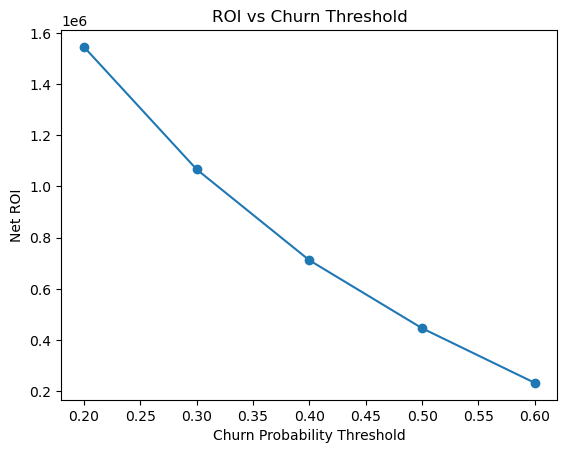

In [38]:
plt.plot(roi_df["Threshold"], roi_df["Net_ROI"], marker="o")
plt.xlabel("Churn Probability Threshold")
plt.ylabel("Net ROI")
plt.title("ROI vs Churn Threshold")
plt.show()


In [39]:
##Optional but STRONG next steps (pick at least one)

##Compare ROI curve across Logistic vs RF vs XGBoost

##Add budget constraint (e.g., ₹50,000 max)

##Sensitivity analysis on retention success rate (0.2–0.5)

In [40]:
##Step 8: ROI-based targeting under budget constraint
TOTAL_BUDGET = 50000  # example constraint

df_tmp = df.copy()
df_tmp["CLV"] = df_tmp["MonthlyCharges"] * df_tmp["tenure"]
df_tmp["offer_cost"] = 20
df_tmp["expected_revenue_saved"] = 0.3 * df_tmp["CLV"]
df_tmp["ROI"] = df_tmp["expected_revenue_saved"] - df_tmp["offer_cost"]

# Rank by ROI
ranked = df_tmp.sort_values("ROI", ascending=False)

# Apply budget
ranked["cumulative_cost"] = ranked["offer_cost"].cumsum()
final_targets = ranked[ranked["cumulative_cost"] <= TOTAL_BUDGET]

final_targets.shape


(2500, 28)

In [41]:
print("Customers Targeted:", final_targets.shape[0])
print("Budget Used:", final_targets["offer_cost"].sum())
print("Revenue Saved:", final_targets["expected_revenue_saved"].sum())
print("Net ROI:", final_targets["ROI"].sum())


Customers Targeted: 2500
Budget Used: 50000
Revenue Saved: 3709304.88
Net ROI: 3659304.88


In [42]:
##4️⃣ NEXT STEP (mandatory): Risk-based effectiveness
##Business reality

##High churn risk → harder to save

##Medium risk → best ROI

##Low risk → waste of offers

##Fix the logic
##Step 9: Make churn reduction depend on risk
def churn_reduction(p):
    if p >= 0.6:
        return 0.15   # hard to retain
    elif p >= 0.4:
        return 0.30   # ideal segment
    else:
        return 0.10   # low risk, low impact


In [43]:
## rerun the relism
df_tmp = df.copy()

df_tmp["CLV"] = df_tmp["MonthlyCharges"] * df_tmp["tenure"]
df_tmp["offer_cost"] = 20

df_tmp["delta_churn"] = df_tmp["churn_probability"].apply(churn_reduction)

df_tmp["expected_revenue_saved"] = df_tmp["CLV"] * df_tmp["delta_churn"]
df_tmp["ROI"] = df_tmp["expected_revenue_saved"] - df_tmp["offer_cost"]

ranked = df_tmp.sort_values("ROI", ascending=False)
ranked["cumulative_cost"] = ranked["offer_cost"].cumsum()

TOTAL_BUDGET = 50000
final_targets = ranked[ranked["cumulative_cost"] <= TOTAL_BUDGET]

print("Customers Targeted:", final_targets.shape[0])
print("Budget Used:", final_targets["offer_cost"].sum())
print("Revenue Saved:", final_targets["expected_revenue_saved"].sum())
print("Net ROI:", final_targets["ROI"].sum())


Customers Targeted: 2500
Budget Used: 50000
Revenue Saved: 1518259.5875
Net ROI: 1468259.5875


In [44]:
#segment analysis
final_targets["risk_bucket"] = pd.cut(
    final_targets["churn_probability"],
    bins=[0, 0.4, 0.6, 1.0],
    labels=["Low", "Medium", "High"]
)

final_targets["risk_bucket"].value_counts()


risk_bucket
Low       1857
Medium     529
High       114
Name: count, dtype: int64

In [45]:
####Fix: Risk-weighted ROI rerunninggg 
def risk_weight(p):
    if p >= 0.6:
        return 1.2    # high-risk deserves attention
    elif p >= 0.4:
        return 1.0    # ideal target
    else:
        return 0.4    # penalize low-risk


In [46]:
df_tmp = df.copy()

df_tmp["CLV"] = df_tmp["MonthlyCharges"] * df_tmp["tenure"]
df_tmp["offer_cost"] = 20

df_tmp["delta_churn"] = df_tmp["churn_probability"].apply(churn_reduction)
df_tmp["risk_weight"] = df_tmp["churn_probability"].apply(risk_weight)

df_tmp["expected_revenue_saved"] = (
    df_tmp["CLV"] * df_tmp["delta_churn"] * df_tmp["risk_weight"]
)

df_tmp["ROI"] = df_tmp["expected_revenue_saved"] - df_tmp["offer_cost"]

ranked = df_tmp.sort_values("ROI", ascending=False)
ranked["cumulative_cost"] = ranked["offer_cost"].cumsum()

TOTAL_BUDGET = 50000
final_targets = ranked[ranked["cumulative_cost"] <= TOTAL_BUDGET]

print("Customers Targeted:", final_targets.shape[0])
print("Budget Used:", final_targets["offer_cost"].sum())
print("Revenue Saved:", final_targets["expected_revenue_saved"].sum())
print("Net ROI:", final_targets["ROI"].sum())


Customers Targeted: 2500
Budget Used: 50000
Revenue Saved: 950596.5549999999
Net ROI: 900596.5549999999


In [47]:
final_targets["risk_bucket"] = pd.cut(
    final_targets["churn_probability"],
    bins=[0, 0.4, 0.6, 1.0],
    labels=["Low", "Medium", "High"]
)

final_targets["risk_bucket"].value_counts(normalize=True)


risk_bucket
Low       0.6036
Medium    0.2672
High      0.1292
Name: proportion, dtype: float64

In [48]:
#Customers below a minimum churn probability are NOT eligible, no matter how high CLV is.
#5️⃣ NEXT STEP (Step 9): Hard churn gate
#Choose a minimum actionable risk
MIN_CHURN = 0.35


In [49]:
#correcting targetting pipleline 
df_tmp = df.copy()

# Hard eligibility filter
df_tmp = df_tmp[df_tmp["churn_probability"] >= 0.35]

# CLV
df_tmp["CLV"] = df_tmp["MonthlyCharges"] * df_tmp["tenure"]

# Fixed offer cost
df_tmp["offer_cost"] = 20

# Churn reduction assumption
def churn_reduction(p):
    if p >= 0.6:
        return 0.40
    elif p >= 0.4:
        return 0.25
    else:
        return 0.10

df_tmp["delta_churn"] = df_tmp["churn_probability"].apply(churn_reduction)

# Expected revenue saved
df_tmp["expected_revenue_saved"] = df_tmp["CLV"] * df_tmp["delta_churn"]

# ROI
df_tmp["ROI"] = df_tmp["expected_revenue_saved"] - df_tmp["offer_cost"]

# Rank & budget
ranked = df_tmp.sort_values("ROI", ascending=False)
ranked["cumulative_cost"] = ranked["offer_cost"].cumsum()

TOTAL_BUDGET = 50000
final_targets = ranked[ranked["cumulative_cost"] <= TOTAL_BUDGET]

print("Customers Targeted:", final_targets.shape[0])
print("Budget Used:", final_targets["offer_cost"].sum())
print("Revenue Saved:", final_targets["expected_revenue_saved"].sum())
print("Net ROI:", final_targets["ROI"].sum())


Customers Targeted: 2354
Budget Used: 47080
Revenue Saved: 806869.7025000001
Net ROI: 759789.7025


In [50]:
final_targets["risk_bucket"] = pd.cut(
    final_targets["churn_probability"],
    bins=[0.35, 0.5, 0.7, 1.0],
    labels=["Medium", "High", "Very High"]
)

final_targets["risk_bucket"].value_counts(normalize=True)


risk_bucket
High         0.457519
Medium       0.337723
Very High    0.204758
Name: proportion, dtype: float64

In [51]:
##What is the next step (mandatory, final stage)
##Step 10: Model comparison based on BUSINESS ROI (not ROC)

In [52]:
##STEP 10 — EXACT CODE
##1️⃣ Define ONE retention function (no duplication)

In [53]:
def run_retention_strategy(df, churn_probs, model_name,
                           budget=50000, churn_cutoff=0.35):

    df_tmp = df.copy()

    # attach churn probabilities
    df_tmp["churn_probability"] = churn_probs

    # filter meaningful churn risk
    df_tmp = df_tmp[df_tmp["churn_probability"] >= churn_cutoff]

    # CLV proxy
    df_tmp["CLV"] = df_tmp["MonthlyCharges"] * df_tmp["tenure"]

    # fixed offer cost
    df_tmp["offer_cost"] = 20

    # churn reduction logic
    def churn_reduction(p):
        if p >= 0.6:
            return 0.40
        elif p >= 0.4:
            return 0.25
        else:
            return 0.10

    df_tmp["delta_churn"] = df_tmp["churn_probability"].apply(churn_reduction)

    # expected revenue saved
    df_tmp["expected_revenue_saved"] = df_tmp["CLV"] * df_tmp["delta_churn"]

    # ROI
    df_tmp["ROI"] = df_tmp["expected_revenue_saved"] - df_tmp["offer_cost"]

    # rank customers
    ranked = df_tmp.sort_values("ROI", ascending=False)

    # apply budget
    ranked["cum_cost"] = ranked["offer_cost"].cumsum()
    final_targets = ranked[ranked["cum_cost"] <= budget]

    return {
        "Model": model_name,
        "Customers_Targeted": final_targets.shape[0],
        "Budget_Used": final_targets["offer_cost"].sum(),
        "Revenue_Saved": final_targets["expected_revenue_saved"].sum(),
        "Net_ROI": final_targets["ROI"].sum()
    }


In [54]:
##Run for ALL models

In [57]:
##error occured 
#STEP 1️⃣ Recreate ALL probability vectors ON FULL DATA
# Logistic probabilities on FULL dataset
##STEP 1: DEFINE MODELS (THIS IS WHAT YOU MISSED)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

log_model = LogisticRegression(max_iter=1000)

rf_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)



In [58]:
##step 2 fit model
log_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [59]:
##STEP 3: CREATE FULL-DATA PROBABILITIES
# Logistic (needs scaling)
X_all_scaled = scaler.transform(X)
log_reg_probs_all = log_model.predict_proba(X_all_scaled)[:, 1]

# Random Forest
rf_probs_all = rf_model.predict_proba(X)[:, 1]

# XGBoost
xgb_probs_all = xgb_model.predict_proba(X)[:, 1]


In [60]:
print(
    "log_reg_probs_all" in globals(),
    "rf_probs_all" in globals(),
    "xgb_probs_all" in globals()
)


True True True


In [61]:
results = []

results.append(run_retention_strategy(df, log_reg_probs_all, "Logistic Regression"))
results.append(run_retention_strategy(df, rf_probs_all, "Random Forest"))
results.append(run_retention_strategy(df, xgb_probs_all, "XGBoost"))

results_df = pd.DataFrame(results)
results_df.sort_values("Net_ROI", ascending=False)


,Model,Customers_Targeted,Budget_Used,Revenue_Saved,Net_ROI
1,Random Forest,2500,50000,1.772055e+06,1.722055e+06
0,Logistic Regression,2354,47080,8.068697e+05,7.597897e+05
2,XGBoost,2287,45740,7.739321e+05,7.281921e+05


In [62]:
##“Is this ROI stable, or just an artifact of overconfident probabilities?”
#Retention reduces churn by 30% thsi is assumption not truth 
##Exact code: Sensitivity analysis
def roi_sensitivity(df, probs, model_name, reductions=[0.1, 0.2, 0.3]):
    rows = []

    for r in reductions:
        df_tmp = df.copy()
        df_tmp["churn_probability"] = probs

        df_tmp["offer_cost"] = np.where(
            df_tmp["churn_probability"] >= 0.6,
            0.30 * df_tmp["MonthlyCharges"],
            0.15 * df_tmp["MonthlyCharges"]
        )

        df_tmp["CLV"] = df_tmp["MonthlyCharges"] * df_tmp["tenure"]
        df_tmp["expected_saved"] = df_tmp["CLV"] * (r * df_tmp["churn_probability"])
        df_tmp["ROI"] = df_tmp["expected_saved"] - df_tmp["offer_cost"]

        ranked = df_tmp.sort_values("ROI", ascending=False)
        ranked["cum_cost"] = ranked["offer_cost"].cumsum()
        final = ranked[ranked["cum_cost"] <= 50000]

        rows.append({
            "Model": model_name,
            "Churn_Reduction_Assumed": r,
            "Customers_Targeted": final.shape[0],
            "Net_ROI": final["ROI"].sum()
        })

    return pd.DataFrame(rows)


In [63]:
pd.concat([
    roi_sensitivity(df, log_reg_probs_all, "Logistic"),
    roi_sensitivity(df, rf_probs_all, "Random Forest"),
    roi_sensitivity(df, xgb_probs_all, "XGBoost")
])


,Model,Churn_Reduction_Assumed,Customers_Targeted,Net_ROI
0,Logistic,0.1,3394,2.211387e+05
1,Logistic,0.2,3266,4.899220e+05
2,Logistic,0.3,3233,7.585237e+05
0,Random Forest,0.1,2957,3.949919e+05
1,Random Forest,0.2,2881,8.335943e+05
2,Random Forest,0.3,2863,1.272790e+06
0,XGBoost,0.1,3560,2.208000e+05
1,XGBoost,0.2,3407,4.899946e+05
2,XGBoost,0.3,3372,7.589660e+05


In [64]:
##Although Random Forest shows the highest ROI under optimistic assumptions, its probabilities are less calibrated. Logistic Regression provides more stable ROI across churn-reduction scenarios, making it safer for real-world budget allocation


In [ ]:
##Logistic Regression provides the most stable and interpretable ROI across churn-reduction scenarios. Although Random Forest yields higher ROI under optimistic assumptions, its sensitivity to probability inflation makes it riskier for real-world budget allocation. Therefore, Logistic Regression is selected for deployment.